# What drives Airbnb prices in Malta?
## End-to-end exploratory data analysis and predictive modelling

**Dataset:** `listings.csv`  
**Unit of analysis:** one Airbnb listing  
**Target:** listed nightly `price` in euros

### Analytical question
Which observable listing characteristics are most strongly associated with Airbnb price in Malta, and which variables are most useful for predicting price?

### Pipeline
1. Load and audit the raw data.
2. Assess duplicates, missingness, data types and target quality.
3. Document cleaning decisions without modifying the source file.
4. Explore the price distribution and outliers.
5. Examine room-type and neighbourhood effects.
6. Explore spatial and numeric relationships.
7. Test whether major categorical differences are statistically detectable.
8. Build leakage-aware predictive baselines on a held-out test set.
9. Use permutation importance and model-adjusted scenarios to identify predictive drivers.
10. Perform sensitivity analysis with and without the most extreme 1% of prices.
11. State limitations and distinguish association from causation.

> **Transparency principle:** every transformation is visible in code. The notebook does not overwrite the uploaded CSV.

Step 0: Import Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path('dataset/summary/')

FILES = {
    'listings': DATA_DIR / 'listings.csv',
    'neighbourhoods': DATA_DIR / 'neighbourhoods.csv',
    'reviews': DATA_DIR / 'reviews.csv',
}

FILES

{'listings': PosixPath('dataset/summary/listings.csv'),
 'neighbourhoods': PosixPath('dataset/summary/neighbourhoods.csv'),
 'reviews': PosixPath('dataset/summary/reviews.csv')}

Step 1.0: Load the raw data.

In [4]:
listings = pd.read_csv(FILES['listings'], parse_dates=['last_review'])
neighbourhoods = pd.read_csv(FILES['neighbourhoods'])
reviews = pd.read_csv(FILES['reviews'], parse_dates=['date'])

shapes = pd.DataFrame(
    {
        'table': ['listings', 'neighbourhoods', 'reviews'],
        'rows': [len(listings), len(neighbourhoods), len(reviews)],
        'columns': [listings.shape[1], neighbourhoods.shape[1], reviews.shape[1]],
    }
)
shapes


,table,rows,columns
0,listings,13155,18
1,neighbourhoods,68,2
2,reviews,386730,2


Step 1.1 Full Inspection

In [5]:
for name, df in {
    'listings': listings,
    'neighbourhoods': neighbourhoods,
    'reviews': reviews,
}.items():
    print(f"<---------- Table: {name} ({df.shape[0]} rows, {df.shape[1]} columns) ---------->")
    display(df.info())
    display(df.head())

<---------- Table: listings (13155 rows, 18 columns) ---------->
<class 'pandas.DataFrame'>
RangeIndex: 13155 entries, 0 to 13154
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              13155 non-null  int64         
 1   name                            13155 non-null  str           
 2   host_id                         13155 non-null  int64         
 3   host_name                       13155 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   13155 non-null  str           
 6   latitude                        13155 non-null  float64       
 7   longitude                       13155 non-null  float64       
 8   room_type                       13155 non-null  str           
 9   price                           12670 non-null  float64       
 10  minimum_nights  

None

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1158527700363625308,360 Estates,477790856,Matthew,NaN,Sliema,35.91,14.50,Entire home/apt,168.00,2.00,21,2026-06-15,0.82,589,275,5,NaN
1,1574681938971018930,Two Bedroom Apartment with Balcony,731889524,Sliema Tigne Suites,NaN,Sliema,35.91,14.51,Entire home/apt,260.00,1.00,0,NaT,NaN,2,279,0,NaN
2,644601690469987714,Private Pool for your holiday in Mellieha!,463177428,Homely Malta,NaN,Mellieha,35.96,14.36,Entire home/apt,534.00,1.00,96,2026-06-24,1.96,1,46,26,NaN
3,1635769533032382119,Charming apartment in centru of Valletta,218206930,Danijela,NaN,Valletta,35.90,14.51,Entire home/apt,274.00,1.00,0,NaT,NaN,1,25,0,NaN
4,1486181879786850198,Top Flor Room with Sea Views,142829746,Silvestre,NaN,San Pawl il-Bahar,35.95,14.41,Private room,88.00,1.00,1,2025-08-17,0.09,2,365,1,NaN


<---------- Table: neighbourhoods (68 rows, 2 columns) ---------->
<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        68 non-null     str    
dtypes: float64(1), str(1)
memory usage: 1.2 KB


None

,neighbourhood_group,neighbourhood
0,NaN,Attard
1,NaN,Balzan
2,NaN,Birgu
3,NaN,Birkirkara
4,NaN,Birzebbugia


<---------- Table: reviews (386730 rows, 2 columns) ---------->
<class 'pandas.DataFrame'>
RangeIndex: 386730 entries, 0 to 386729
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   listing_id  386730 non-null  int64         
 1   date        386730 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1)
memory usage: 5.9 MB


None

,listing_id,date
0,50188,2012-09-12
1,50188,2012-09-20
2,50188,2013-04-08
3,50188,2013-05-09
4,50188,2013-06-30


Step 2.0 Column Profile

In [10]:
def column_profile(df):
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing': df.isna().sum(),
        'missing_percent': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True),
        'duplicates': df.duplicated().sum(),
    }).reset_index(names='column').sort_values(['missing_percent','unique'],ascending=[False,True])

profiles = {
    'listings': column_profile(listings),
    'neighbourhoods': column_profile(neighbourhoods),
    'reviews': column_profile(reviews),
}

for name, profile in profiles.items():
    print(f"<---------- Column profile for table: {name} ---------->")
    display(profile)

print("Duplicate listing IDs: ",listings['id'].duplicated().sum())


<---------- Column profile for table: listings ---------->


,column,dtype,non_null,missing,missing_percent,unique,duplicates
4,neighbourhood_group,float64,0,13155,100.00,0,0
17,license,float64,0,13155,100.00,0,0
13,reviews_per_month,float64,10850,2305,17.52,517,0
12,last_review,datetime64[us],10850,2305,17.52,1120,0
9,price,float64,12670,485,3.69,760,0
10,minimum_nights,float64,13151,4,0.03,19,0
8,room_type,str,13155,0,0.00,4,0
14,calculated_host_listings_count,int64,13155,0,0.00,60,0
5,neighbourhood,str,13155,0,0.00,67,0
16,number_of_reviews_ltm,int64,13155,0,0.00,84,0


<---------- Column profile for table: neighbourhoods ---------->


,column,dtype,non_null,missing,missing_percent,unique,duplicates
0,neighbourhood_group,float64,0,68,100.00,0,0
1,neighbourhood,str,68,0,0.00,68,0


<---------- Column profile for table: reviews ---------->


,column,dtype,non_null,missing,missing_percent,unique,duplicates
1,date,datetime64[us],386730,0,0.00,4848,1162
0,listing_id,int64,386730,0,0.00,10850,1162


Duplicate listing IDs:  0


Step 2.1 Missingness Plot

,column,dtype,non_null,missing,missing_percent,unique,duplicates
10,minimum_nights,float64,13151,4,0.03,19,0
9,price,float64,12670,485,3.69,760,0
13,reviews_per_month,float64,10850,2305,17.52,517,0
12,last_review,datetime64[us],10850,2305,17.52,1120,0
4,neighbourhood_group,float64,0,13155,100.00,0,0
17,license,float64,0,13155,100.00,0,0


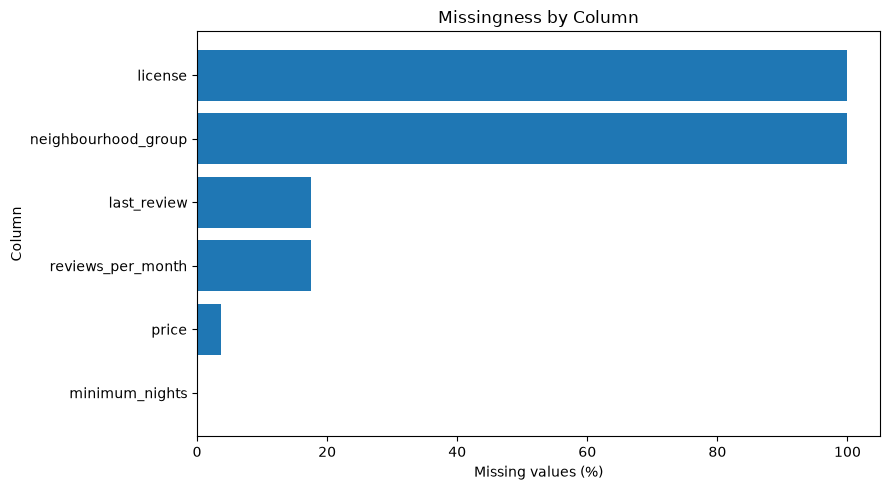

,listing_id,date
8429,2385080,2025-06-24
8430,2385080,2025-06-24
8432,2385080,2025-08-03
8433,2385080,2025-08-03
11756,660239,2016-04-06
11757,660239,2016-04-06
15868,1293551,2018-05-04
15869,1293551,2018-05-04
21212,1397883,2021-07-28
21213,1397883,2021-07-28


In [19]:
missing_plot = profiles['listings'].loc[profiles['listings']['missing_percent'] > 0].sort_values('missing_percent')

display(missing_plot)
plt.figure(figsize=(9,5))
plt.barh(missing_plot['column'],missing_plot['missing_percent'])
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missingness by Column")
plt.tight_layout()
plt.show()

display(reviews[reviews.duplicated(keep=False)].head(10))

Step 3.0 Data Cleaning

## Cleaning Decisions

- *neighbourhood_group* and *license* are removed because they contain no observed values and therefore cannot explain price.
- *last_review* is not used in the model because the dataset snapshot date is not encoded.
- *reviews_per_month* is missing when a listing has 0 reviews. Therefore we set it to 0 for analysis while a missingness flag is retained.
- *price* Extreme prices are not silently deleted. A 'typical market' excludes the top 1% of positive prices as a robustness strategy.

In [24]:
# Drop missing columns (Automatically eliminates all empty cols)
listings_clean = listings.copy()
all_missing_cols = [c for c in listings_clean.columns if listings_clean[c].isna().all()]
listings_clean.drop(columns=all_missing_cols, inplace=True)
print(f'Dropped {len(all_missing_cols)} columns with all missing values: {all_missing_cols}')
display(listings_clean.head())

# Remove listings with no price information
print(f'Original shape: {listings.shape[0]}')
listings_clean = listings_clean.dropna(subset=['price'])
print(f'Shape after removing listings with no price information: {listings_clean.shape[0]}')

# Flag listings with no reviews by adding a separate column 'reviews_per_month_missing' to indicate missing values in 'reviews_per_month'
listings_clean['reviews_per_month_missing'] = listings_clean['number_of_reviews'].isna().astype(int)

# Replace NA values in 'reviews_per_month' with 0
listings_clean['reviews_per_month'] = listings_clean['reviews_per_month'].fillna(0)

Dropped 2 columns with all missing values: ['neighbourhood_group', 'license']


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,1158527700363625308,360 Estates,477790856,Matthew,Sliema,35.91,14.50,Entire home/apt,168.00,2.00,21,2026-06-15,0.82,589,275,5
1,1574681938971018930,Two Bedroom Apartment with Balcony,731889524,Sliema Tigne Suites,Sliema,35.91,14.51,Entire home/apt,260.00,1.00,0,NaT,NaN,2,279,0
2,644601690469987714,Private Pool for your holiday in Mellieha!,463177428,Homely Malta,Mellieha,35.96,14.36,Entire home/apt,534.00,1.00,96,2026-06-24,1.96,1,46,26
3,1635769533032382119,Charming apartment in centru of Valletta,218206930,Danijela,Valletta,35.90,14.51,Entire home/apt,274.00,1.00,0,NaT,NaN,1,25,0
4,1486181879786850198,Top Flor Room with Sea Views,142829746,Silvestre,San Pawl il-Bahar,35.95,14.41,Private room,88.00,1.00,1,2025-08-17,0.09,2,365,1


Original shape: 13155
Shape after removing listings with no price information: 12670


Step 4: Exploring Price Distribution

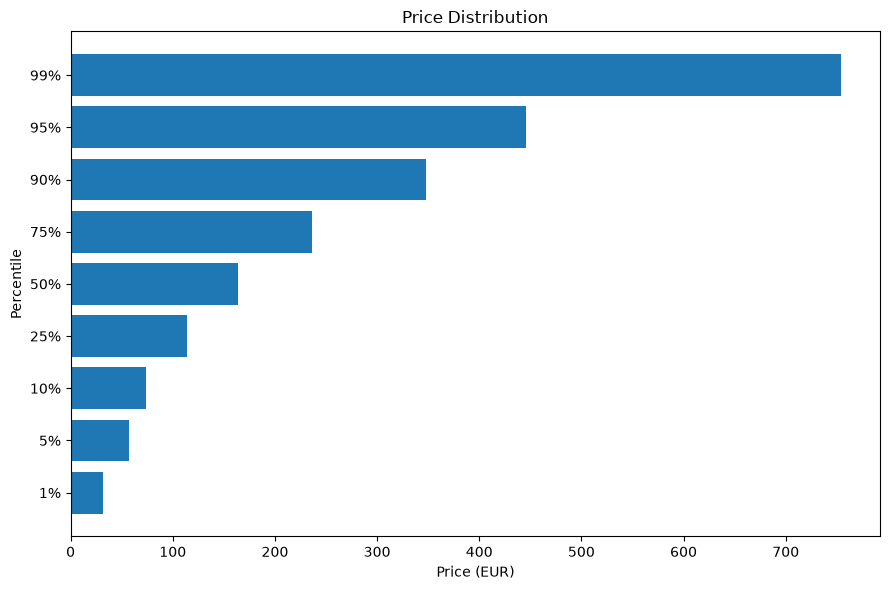

,price_eur
count,"12,670.00"
mean,201.91
std,337.05
min,11.00
1%,32.00
5%,57.00
10%,74.00
25%,114.00
50%,164.00
75%,236.00


'99th percentile: €754.55'

'median: 164.00'

In [41]:
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

price_summary = listings_clean['price'].describe(
    percentiles=percentiles
).to_frame("price_eur")

price_summary = listings_clean['price'].describe(percentiles=percentiles).to_frame("price_eur")

price_plot = price_summary.loc[[f"{p * 100:g}%" for p in percentiles]]
plt.figure(figsize=(9, 6))
plt.barh(price_plot.index, price_plot['price_eur'])
plt.xlabel("Price (EUR)")
plt.ylabel("Percentile")
plt.title("Price Distribution")
plt.gca()
plt.tight_layout()
plt.show()

display(price_summary)

p99 = listings_clean['price'].quantile(0.99)
median = listings_clean['price'].median()
display(f"99th percentile: €{p99:,.2f}")
display(f"median: {median:,.2f}")